<a href="https://colab.research.google.com/github/Tolureis/CMPE-403-Fundamentals-of-Image-Processing/blob/main/Wavelets_Opencv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Haar wavelet kernels (low-pass and high-pass)
lp_row = np.array([[1/np.sqrt(2), 1/np.sqrt(2)]], dtype=np.float32)
hp_row = np.array([[1/np.sqrt(2), -1/np.sqrt(2)]], dtype=np.float32)
lp_col = np.array([[1/np.sqrt(2)], [1/np.sqrt(2)]], dtype=np.float32)
hp_col = np.array([[1/np.sqrt(2)], [-1/np.sqrt(2)]], dtype=np.float32)

# Perform a single-level 2-D Haar wavelet transform using OpenCV for filtering.
def haar_dwt2_cv(img):
    # Ensure even dimensions
    h, w = img.shape
    if h % 2 != 0:
        img = img[:-1, :]
        h -= 1
    if w % 2 != 0:
        img = img[:, :-1]
        w -= 1
    img = img.astype(np.float32)
    # Convolve along rows
    low_rows = cv2.filter2D(img, -1, lp_row)
    high_rows = cv2.filter2D(img, -1, hp_row)
    # Downsample columns
    low_rows_ds = low_rows[:, ::2]
    high_rows_ds = high_rows[:, ::2]
    # Convolve along columns
    LL_conv = cv2.filter2D(low_rows_ds, -1, lp_col)
    LH_conv = cv2.filter2D(low_rows_ds, -1, hp_col)
    HL_conv = cv2.filter2D(high_rows_ds, -1, lp_col)
    HH_conv = cv2.filter2D(high_rows_ds, -1, hp_col)
    # Downsample rows
    LL = LL_conv[::2, :]
    LH = LH_conv[::2, :]
    HL = HL_conv[::2, :]
    HH = HH_conv[::2, :]
    return LL, LH, HL, HH

# Reconstruct an image from its Haar sub-bands

def haar_idwt2_cv(LL, LH, HL, HH):
    h2, w2 = LL.shape
    rows_low = np.zeros((h2 * 2, w2), dtype=np.float32)
    rows_high = np.zeros((h2 * 2, w2), dtype=np.float32)
    rows_low[0::2, :] = (LL + LH) / np.sqrt(2)
    rows_low[1::2, :] = (LL - LH) / np.sqrt(2)
    rows_high[0::2, :] = (HL + HH) / np.sqrt(2)
    rows_high[1::2, :] = (HL - HH) / np.sqrt(2)
    rec = np.zeros((h2 * 2, w2 * 2), dtype=np.float32)
    rec[:, 0::2] = (rows_low + rows_high) / np.sqrt(2)
    rec[:, 1::2] = (rows_low - rows_high) / np.sqrt(2)
    return rec

# Compute Gaussian pyramid approximations using cv2.pyrDown

def gaussian_pyramid_levels(img, levels=3):
    pyr = [img]
    current = img
    for _ in range(levels):
        current = cv2.pyrDown(current)
        pyr.append(current)
    return pyr

In [ ]:
# Provide the path to an external image file. If None or if reading fails, a sample image will be used.
image_path = "/content/shrek.jpg"  # e.g., '/mnt/data/your_image.jpg'

# Load image in grayscale using OpenCV
try:
    if image_path is not None:
        original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if original is None:
            raise IOError
    else:
        raise IOError
except Exception:
    # Use an example image from OpenCV's samples if available
    original = None
    try:
        sample_path = cv2.samples.findFile('lena.jpg')
        original = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    except Exception:
        pass
    import numpy as np
    if original is None:
        # If sample image isn't available, create a simple test pattern
        original = np.tile(np.arange(256, dtype=np.uint8), (256, 1))

print('Image shape:', original.shape)


Image shape: (278, 181)


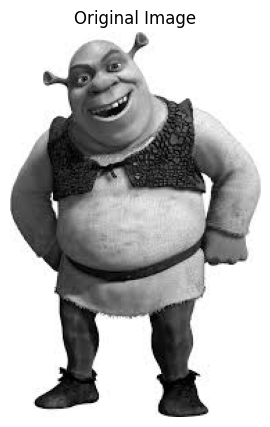

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(original, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

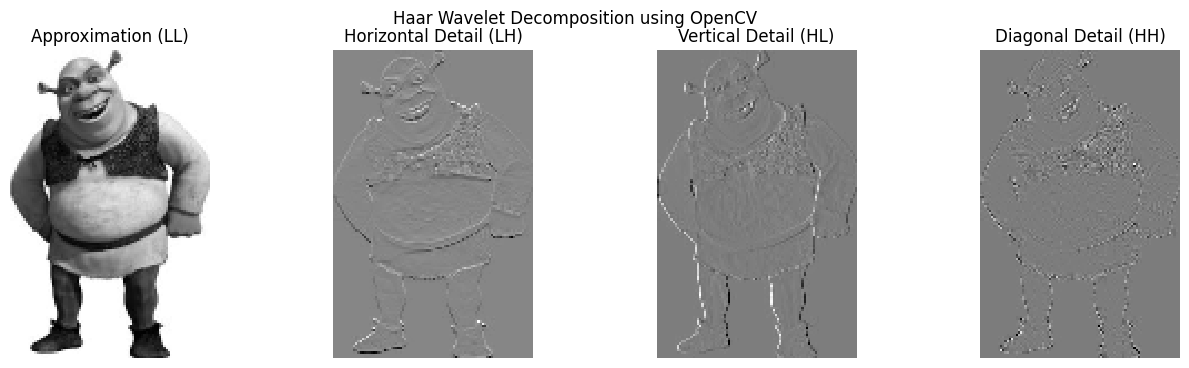

In [ ]:
LL, LH, HL, HH = haar_dwt2_cv(original)

# Display sub-bands
titles = ['Approximation (LL)', 'Horizontal Detail (LH)', 'Vertical Detail (HL)', 'Diagonal Detail (HH)']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, data, title in zip(axes, [LL, LH, HL, HH], titles):
    # Normalize for visualization
    norm_data = (data - data.min()) / (data.max() - data.min() + 1e-5)
    ax.imshow(norm_data, cmap='gray', interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')
plt.suptitle('Haar Wavelet Decomposition using OpenCV')
plt.show()

Reconstruction relative error: 1.51e-01


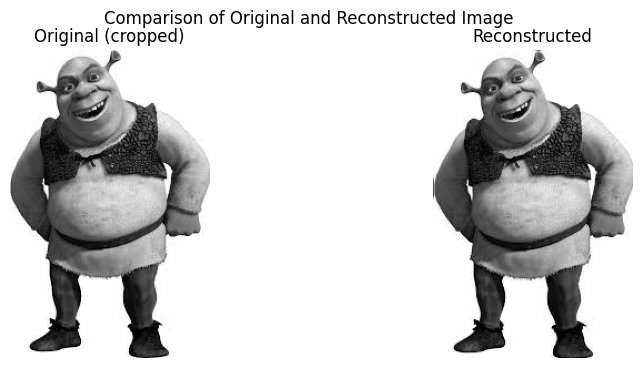

In [ ]:
reconstructed = haar_idwt2_cv(LL, LH, HL, HH)

crop_h, crop_w = reconstructed.shape
original_cropped = original[:crop_h, :crop_w].astype(np.float32)

error = np.linalg.norm(original_cropped - reconstructed) / np.linalg.norm(original_cropped)
print(f'Reconstruction relative error: {error:.2e}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(original_cropped, cmap='gray')
axes[0].set_title('Original (cropped)')
axes[0].axis('off')
axes[1].imshow(reconstructed, cmap='gray')
axes[1].set_title('Reconstructed')
axes[1].axis('off')
plt.suptitle('Comparison of Original and Reconstructed Image')
plt.show()

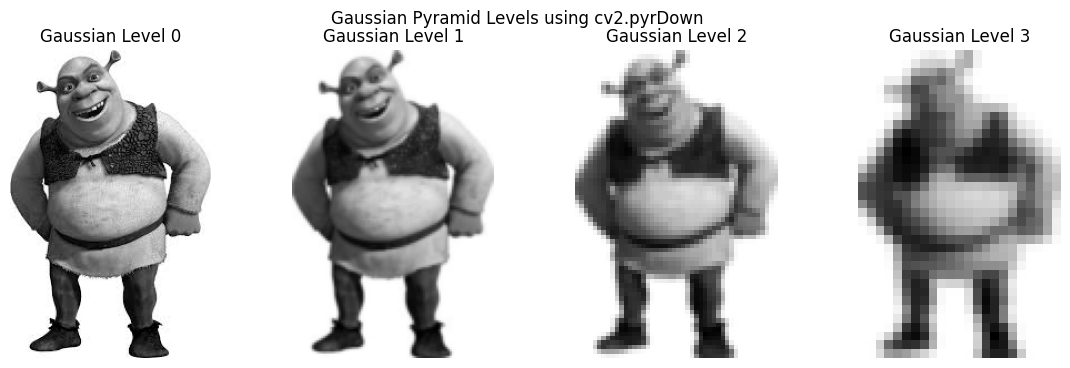

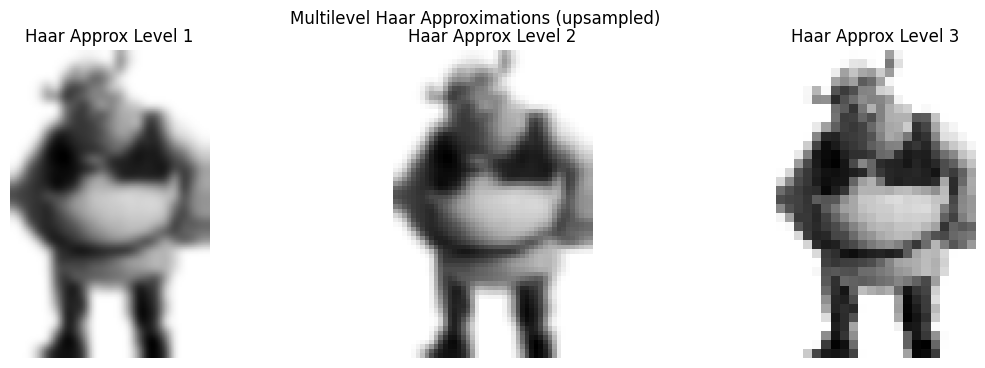

In [ ]:
# Gaussian pyramid using cv2.pyrDown
levels = 3
pyramid = gaussian_pyramid_levels(original.astype(np.float32), levels)

# Visualize Gaussian pyramid levels
fig, axes = plt.subplots(1, levels + 1, figsize=(14, 4))
for i in range(levels + 1):
    approx = pyramid[i]
    norm_approx = (approx - approx.min()) / (approx.max() - approx.min() + 1e-5)
    axes[i].imshow(norm_approx, cmap='gray')
    axes[i].set_title(f'Gaussian Level {i}')
    axes[i].axis('off')
plt.suptitle('Gaussian Pyramid Levels using cv2.pyrDown')
plt.show()

# Multi-level Haar decomposition using repeated DWT
coeffs = []
current = original
for lvl in range(levels):
    LLc, LHc, HLc, HHc = haar_dwt2_cv(current)
    coeffs.append((LHc, HLc, HHc))
    current = LLc

approximation = current

# Visualize Haar approximations by upsampling with cv2.pyrUp
fig2, axes2 = plt.subplots(1, levels, figsize=(14, 4))
for i in range(levels):
    approx = approximation.copy()
    # Upsample to match intermediate levels
    for _ in range(levels - i - 1):
        approx = cv2.pyrUp(approx)
    norm_approx = (approx - approx.min()) / (approx.max() - approx.min() + 1e-5)
    axes2[i].imshow(norm_approx, cmap='gray')
    axes2[i].set_title(f'Haar Approx Level {i+1}')
    axes2[i].axis('off')
plt.suptitle('Multilevel Haar Approximations (upsampled)')
plt.show()

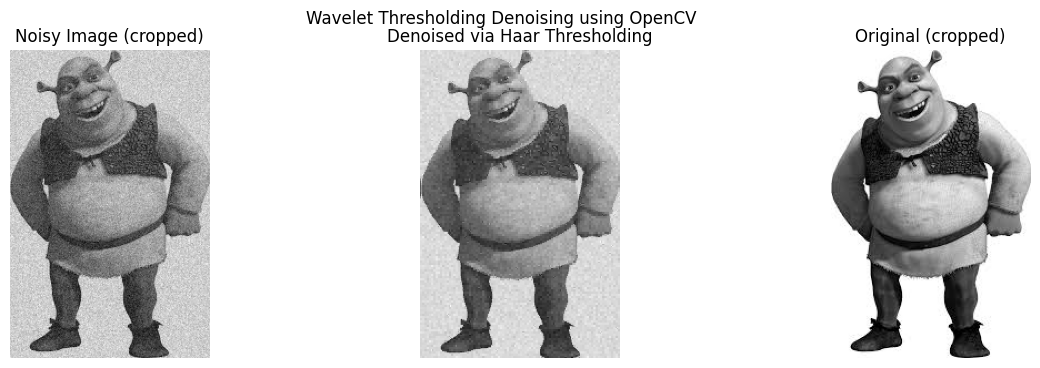

In [ ]:
# Add Gaussian noise
noise_sigma = 20.0
noisy = original.astype(np.float32) + noise_sigma * np.random.standard_normal(original.shape)

# Haar decomposition of noisy image
LLn, LHn, HLn, HHn = haar_dwt2_cv(noisy)

# Hard thresholding
threshold = 3 * noise_sigma
LHn_thresh = np.where(np.abs(LHn) > threshold, LHn, 0)
HLn_thresh = np.where(np.abs(HLn) > threshold, HLn, 0)
HHn_thresh = np.where(np.abs(HHn) > threshold, HHn, 0)

reconstructed_denoised = haar_idwt2_cv(LLn, LHn_thresh, HLn_thresh, HHn_thresh)

crop_h, crop_w = reconstructed_denoised.shape
original_noisy_cropped = noisy[:crop_h, :crop_w]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(original_noisy_cropped, cmap='gray')
axes[0].set_title('Noisy Image (cropped)')
axes[0].axis('off')
axes[1].imshow(reconstructed_denoised, cmap='gray')
axes[1].set_title('Denoised via Haar Thresholding')
axes[1].axis('off')
axes[2].imshow(original[:crop_h, :crop_w], cmap='gray')
axes[2].set_title('Original (cropped)')
axes[2].axis('off')
plt.suptitle('Wavelet Thresholding Denoising using OpenCV')
plt.show()